In [2]:
from model_ranking import load_h5, get_unique_colourmap, get_roi_slice
import matplotlib.pyplot as plt
import numpy as np
from plantseg.functionals.dataprocessing.labelprocessing import set_background_to_value, set_biggest_instance_to_zero, relabel_segmentation
from plantseg.functionals.segmentation import dt_watershed, gasp

INFO: P [MainThread] 2026-07-23 09:44:47,432 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
PNAS_gt_path = "/scratch/talks/data/PNAS/test/36hrs_plant18_trim-acylYFP.h5"
gt = load_h5(PNAS_gt_path, "label")
raw = load_h5(PNAS_gt_path, "raw")

# PNAS to PNAS

In [4]:
pred_path ="/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/PNAS_to_PNAS_gap/consistency/P_full/p_model_UNet1/norm_50_950/none/predictions/36hrs_plant18_trim-acylYFP_predictions.h5"
IN_pred = load_h5(pred_path, "segmentation")
pred = load_h5(pred_path, "predictions")
patch_index = load_h5(pred_path, "patch_index")
MAP_scores = load_h5(pred_path, "MAP_05_095")

In [5]:
gt.shape

(189, 512, 512)

In [6]:
MAP_scores[:33]

array([0.70349765, 0.661429  , 0.6129447 , 0.6737482 , 0.7781665 ,
       0.6727072 , 0.6720059 , 0.70514816, 0.78696066, 0.746599  ,
       0.73584807, 0.69978255, 0.77050304, 0.6841933 , 0.7236784 ,
       0.7536108 , 0.7945286 , 0.75646037, 0.7251442 , 0.67543024,
       0.7280872 , 0.7502398 , 0.6492012 , 0.6557522 , 0.6668047 ,
       0.7435938 , 0.6850639 , 0.68952495, 0.687417  , 0.64305514,
       0.71307784, 0.6579344 , 0.70880485], dtype=float32)

In [7]:
print(IN_pred.shape)

(756, 1, 1, 256, 256)


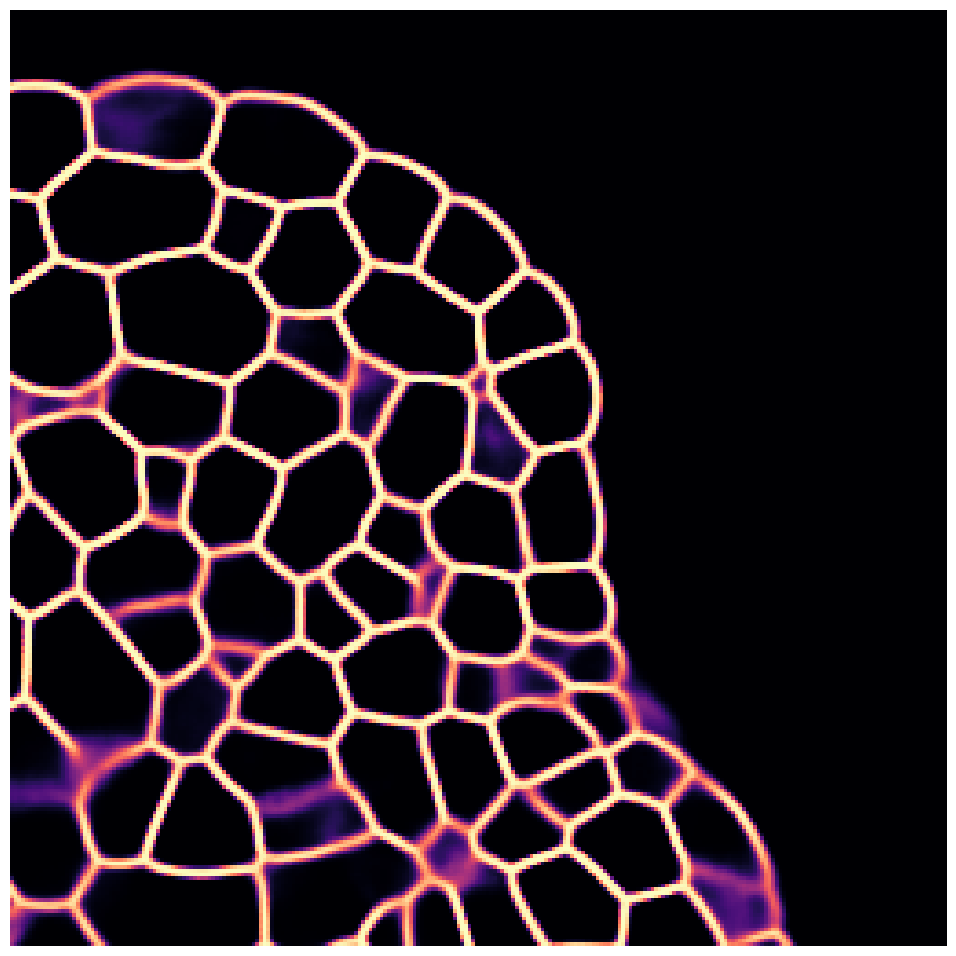

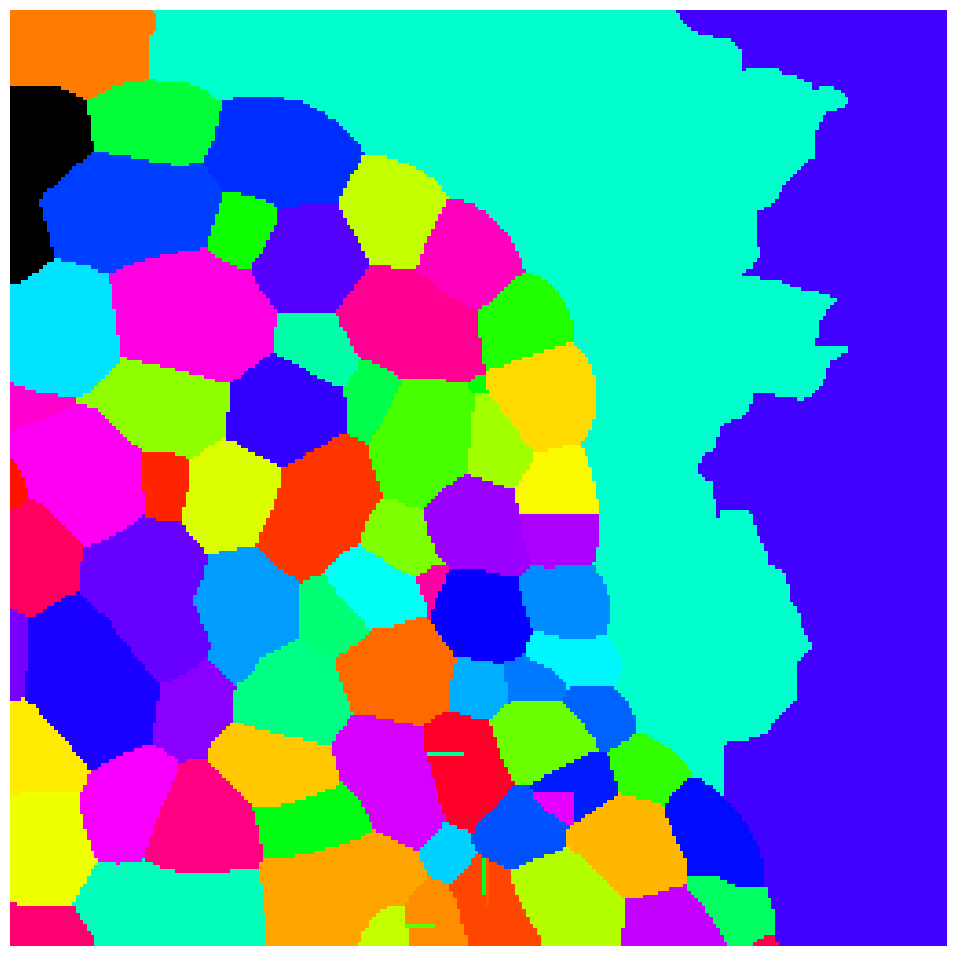

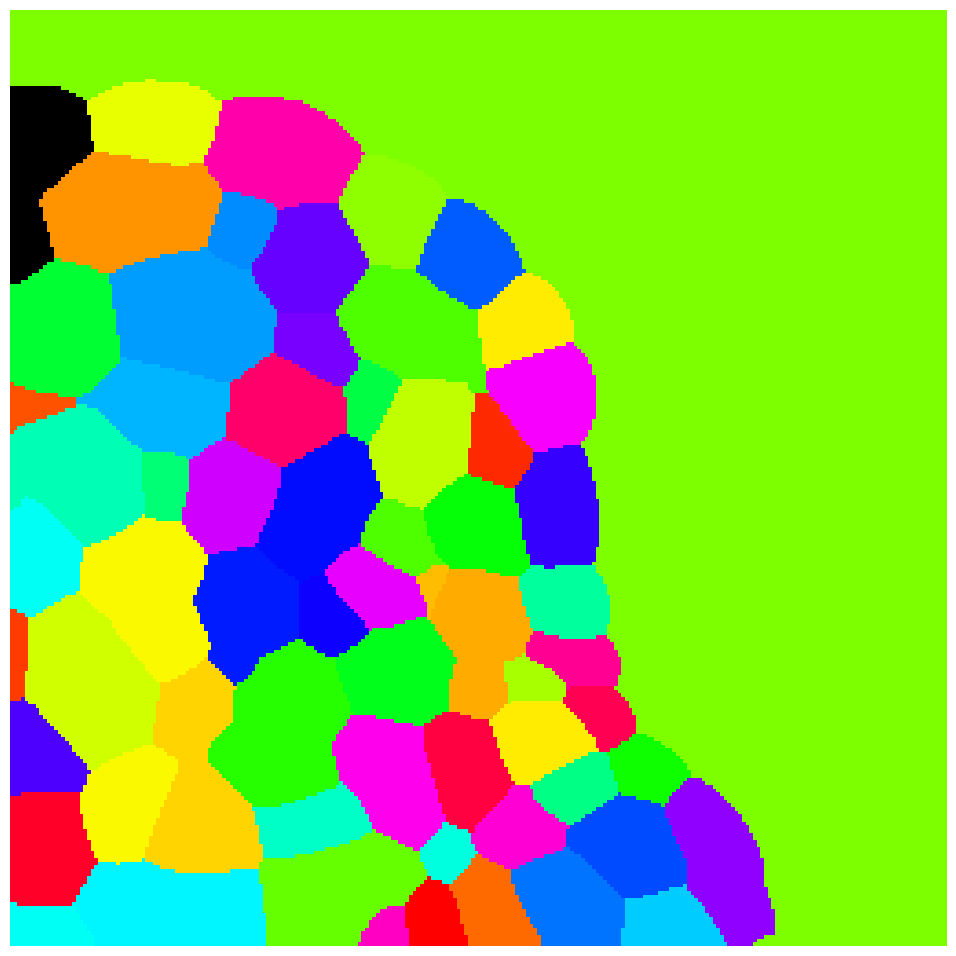

In [8]:
pred_i = pred[1]
pred_wt = dt_watershed(pred_i.squeeze(), threshold=0.8, stacked=False, min_size=5)
gasp_pred = gasp(pred_i.squeeze(), pred_wt, post_minsize=50, beta=0.8)

_ = plt.figure(figsize=(10, 10))
_ = plt.imshow(pred_i.squeeze(), cmap="magma")
plt.tight_layout()
_ = plt.axis("off")
plt.show()

_ = plt.figure(figsize=(10, 10))
_ = plt.imshow(pred_wt, cmap=get_unique_colourmap(pred_wt), interpolation="none")
plt.tight_layout()
_ = plt.axis("off")
plt.show()

_ = plt.figure(figsize=(10, 10))
_ = plt.imshow(gasp_pred, cmap=get_unique_colourmap(gasp_pred), interpolation="none")
plt.tight_layout()
_ = plt.axis("off")
plt.show()

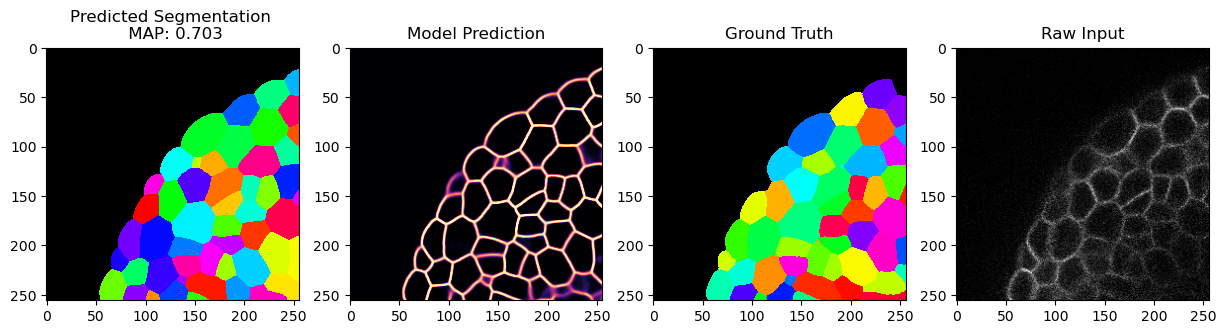

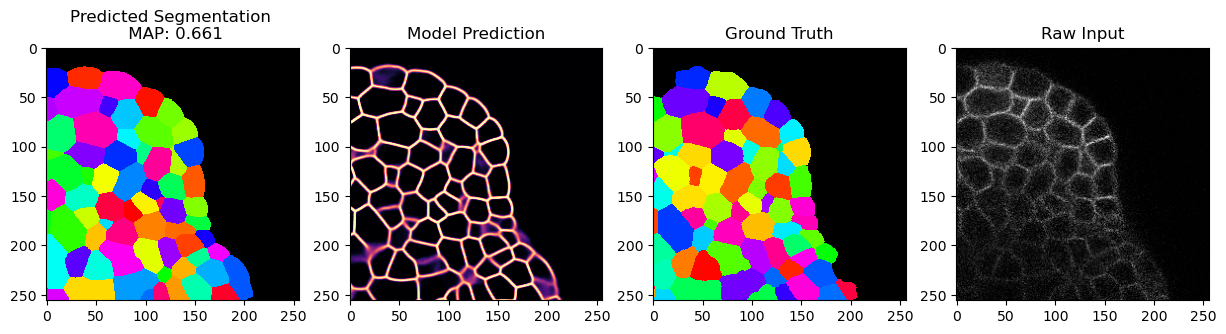

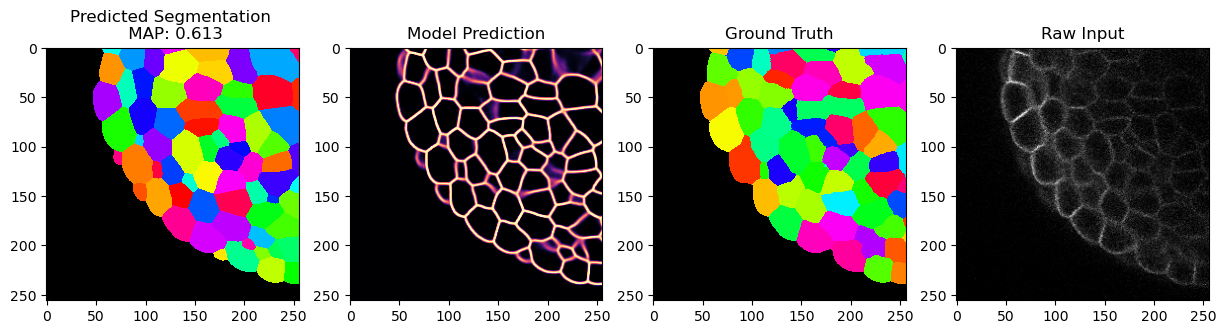

In [9]:
for i in range(3):
    patch_roi = get_roi_slice(patch_index[i])
    _, axs = plt.subplots(1, 4, figsize=(15, 5))
    axs[0].imshow(IN_pred[i].squeeze(), cmap=get_unique_colourmap(IN_pred[i]), interpolation='nearest')
    axs[0].set_title(f"Predicted Segmentation \n MAP: {MAP_scores[i]:.3f}")
    axs[1].imshow(pred[i].squeeze(), cmap="magma")
    axs[1].set_title(f"Model Prediction")
    axs[2].imshow(gt[patch_roi].squeeze(), cmap=get_unique_colourmap(gt[i]), interpolation='nearest')
    axs[2].set_title(f"Ground Truth")
    axs[3].imshow(raw[patch_roi].squeeze(), cmap="gray")
    axs[3].set_title(f"Raw Input")
    plt.show()

# FlyWing to PNAS

In [10]:
pred_path ="/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_PNAS_gap/consistency/P_full/fw_model_Unet2/norm_50_950/none/predictions/36hrs_plant18_trim-acylYFP_predictions.h5"
IN_pred = load_h5(pred_path, "segmentation")
pred = load_h5(pred_path, "predictions")
patch_index = load_h5(pred_path, "patch_index")
MAP_scores = load_h5(pred_path, "MAP_05_095")

In [11]:
MAP_scores[:33]

array([0.615905  , 0.5358096 , 0.5891389 , 0.5433573 , 0.61789554,
       0.6088113 , 0.5744512 , 0.50719446, 0.5706393 , 0.5419938 ,
       0.6083628 , 0.5530345 , 0.5634734 , 0.5746435 , 0.511524  ,
       0.61179334, 0.5236252 , 0.5183795 , 0.48905793, 0.5571533 ,
       0.5226383 , 0.48918885, 0.45684597, 0.49340954, 0.53677803,
       0.48499382, 0.47401538, 0.54638165, 0.505403  , 0.4857582 ,
       0.5057715 , 0.4362666 , 0.4891557 ], dtype=float32)

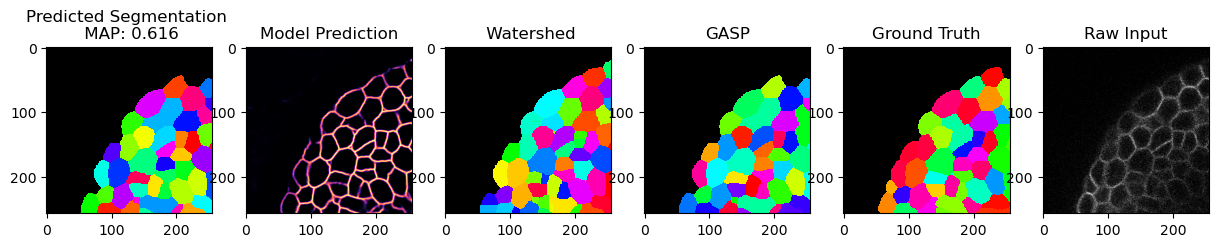

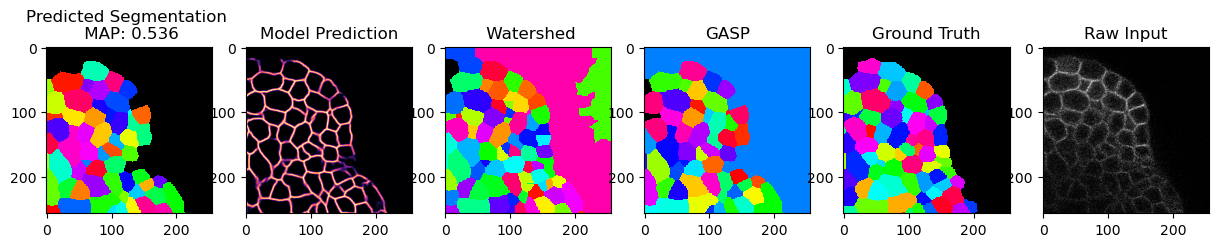

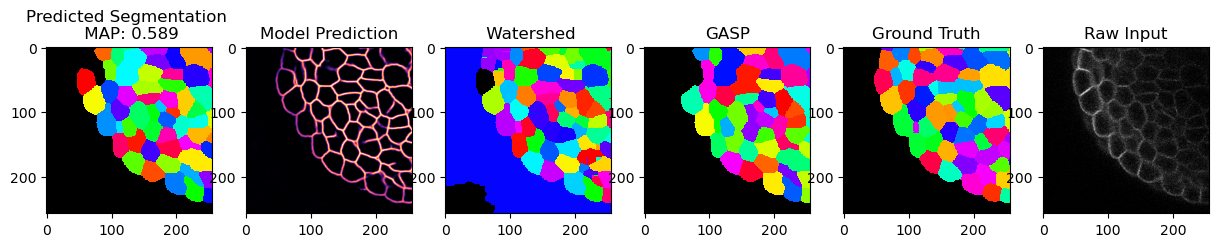

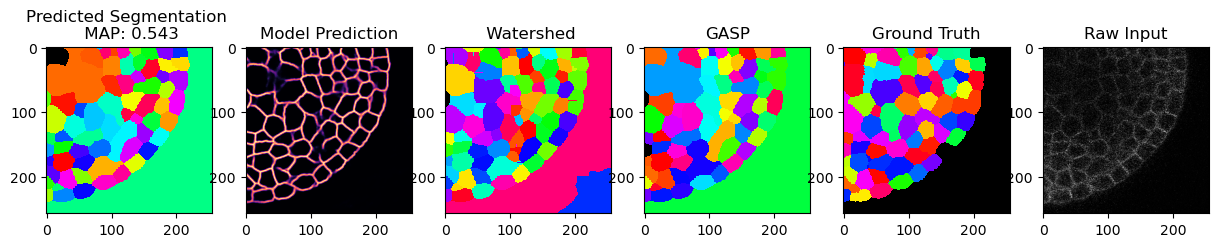

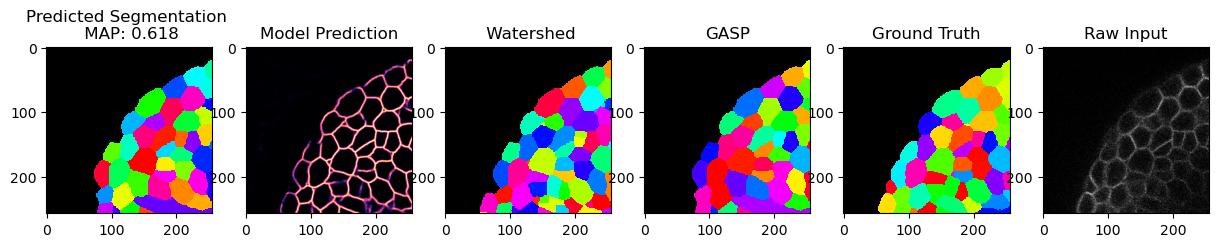

In [12]:
for i in range(5):
    patch_roi = get_roi_slice(patch_index[i])
    pred_wt = dt_watershed(pred[i].squeeze(), threshold=0.5, stacked=False, min_size=5)
    gasp_pred = gasp(pred[i].squeeze(), pred_wt, post_minsize=50, beta=0.5)
    _, axs = plt.subplots(1, 6, figsize=(15, 5))
    axs[0].imshow(IN_pred[i].squeeze(), cmap=get_unique_colourmap(IN_pred[i]), interpolation='nearest')
    axs[0].set_title(f"Predicted Segmentation \n MAP: {MAP_scores[i]:.3f}")
    axs[1].imshow(pred[i].squeeze(), cmap="magma")
    axs[1].set_title(f"Model Prediction")
    axs[2].imshow(pred_wt, cmap=get_unique_colourmap(pred_wt), interpolation='nearest')
    axs[2].set_title(f" Watershed")
    axs[3].imshow(gasp_pred, cmap=get_unique_colourmap(gasp_pred), interpolation='nearest')
    axs[3].set_title(f"GASP")
    axs[4].imshow(gt[patch_roi].squeeze(), cmap=get_unique_colourmap(gt[i]), interpolation='nearest')
    axs[4].set_title(f"Ground Truth")
    axs[5].imshow(raw[patch_roi].squeeze(), cmap="gray")
    axs[5].set_title(f"Raw Input")
    plt.show()

# Ovules to PNAS

In [13]:
pred_path ="/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/Ovules_to_PNAS_gap/consistency/P_fullslice/ov_model_UNet1/norm_50_950/none/predictions/24hrs_plant18_trim-acylYFP_predictions.h5"
IN_pred = load_h5(pred_path, "segmentation")
pred = load_h5(pred_path, "predictions")
patch_index = load_h5(pred_path, "patch_index")
MAP_scores = load_h5(pred_path, "MAP_05_095")

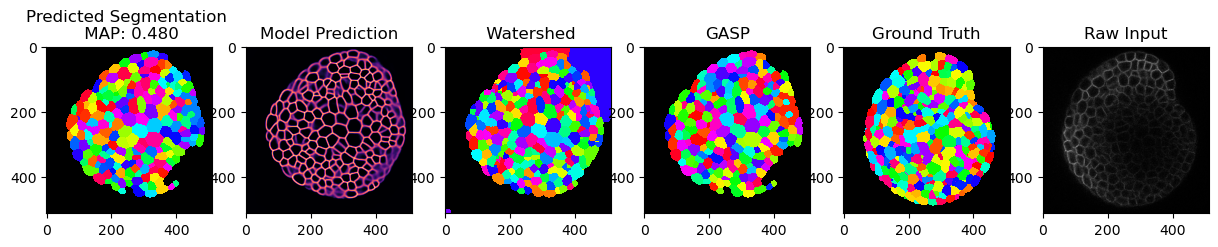

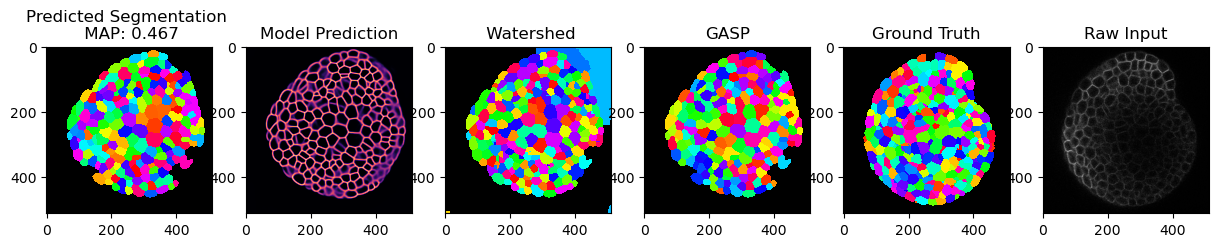

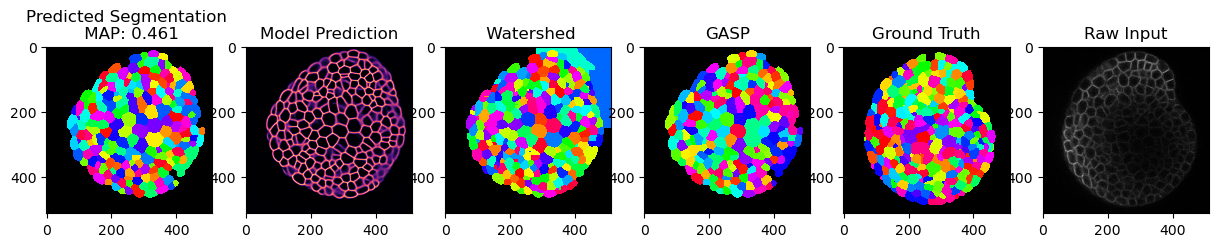

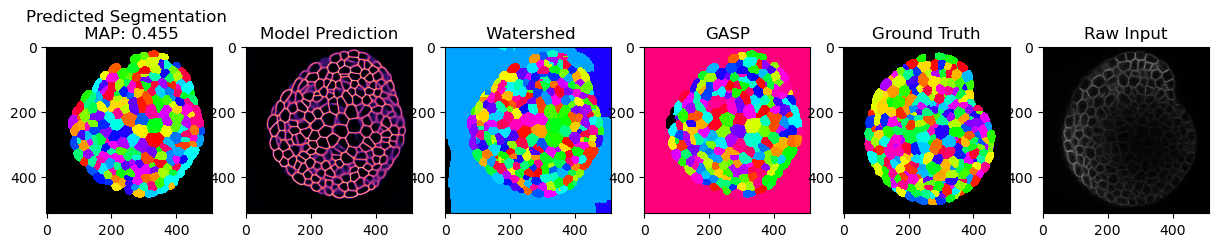

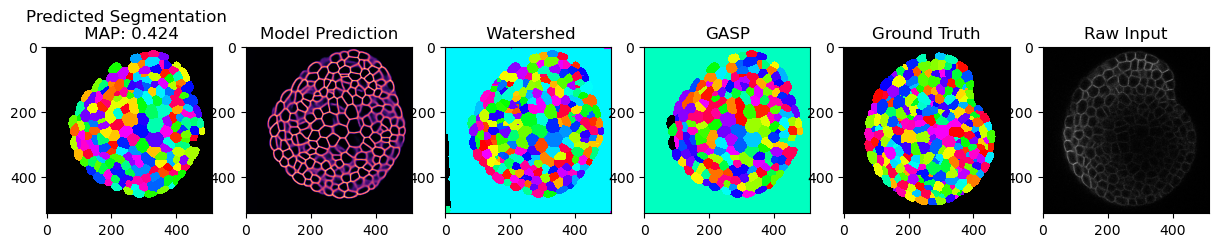

In [15]:
for i in range(20, 25):
    patch_roi = get_roi_slice(patch_index[i])
    pred_wt = dt_watershed(pred[i].squeeze(), threshold=0.5, stacked=False, min_size=5)
    gasp_pred = gasp(pred[i].squeeze(), pred_wt, post_minsize=50, beta=0.5)
    _, axs = plt.subplots(1, 6, figsize=(15, 5))
    axs[0].imshow(IN_pred[i].squeeze(), cmap=get_unique_colourmap(IN_pred[i]), interpolation='nearest')
    axs[0].set_title(f"Predicted Segmentation \n MAP: {MAP_scores[i]:.3f}")
    axs[1].imshow(pred[i].squeeze(), cmap="magma")
    axs[1].set_title(f"Model Prediction")
    axs[2].imshow(pred_wt, cmap=get_unique_colourmap(pred_wt), interpolation='nearest')
    axs[2].set_title(f" Watershed")
    axs[3].imshow(gasp_pred, cmap=get_unique_colourmap(gasp_pred), interpolation='nearest')
    axs[3].set_title(f"GASP")
    axs[4].imshow(gt[patch_roi].squeeze(), cmap=get_unique_colourmap(gt[i]), interpolation='nearest')
    axs[4].set_title(f"Ground Truth")
    axs[5].imshow(raw[patch_roi].squeeze(), cmap="gray")
    axs[5].set_title(f"Raw Input")
    plt.show()